1. Import Libraries and Load Data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load cleaned data
df = pd.read_csv("online_retail_cleaned.csv")

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month,Day_Name,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,2010-12,Wednesday,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8


2. Understand the RFM Calculation

Recency   = Days since last purchase

Frequency = Number of unique orders

Monetary  = Total revenue generated

3. Define the Analysis Date

In [41]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Last Transaction Date:", df["InvoiceDate"].max())
print("Analysis Date:", analysis_date)

Last Transaction Date: 2011-12-09 12:50:00
Analysis Date: 2011-12-10 12:50:00


4. Calculate RFM Values

In [42]:
rfm = (df.groupby("CustomerID").agg(Recency=("InvoiceDate",lambda x: (analysis_date - x.max()).days),
         Frequency=("InvoiceNo", "nunique"),Monetary=("Revenue","sum")).reset_index())

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [43]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


5. Check RFM Distributions

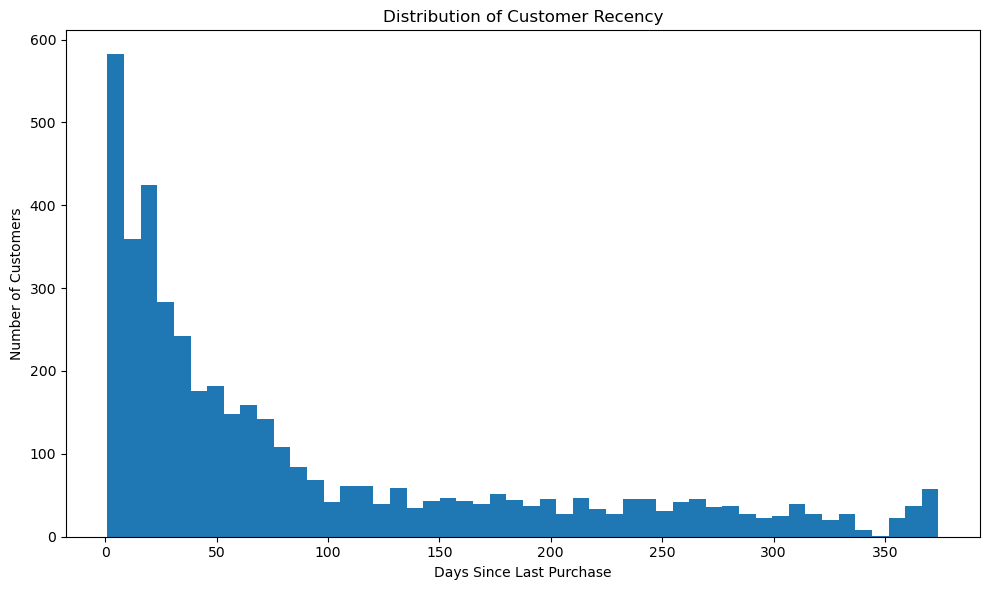

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(rfm["Recency"],bins=50)

plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

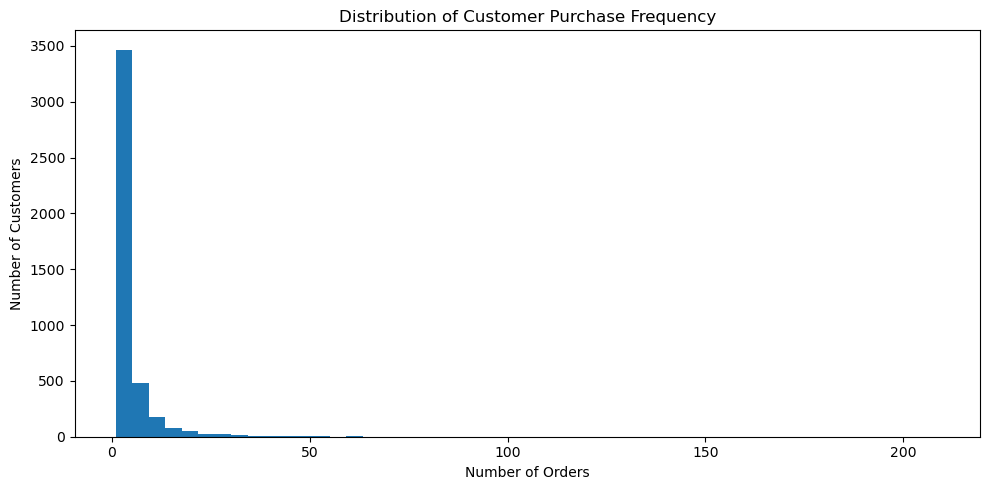

In [45]:
# Frequency

plt.figure(figsize=(10, 5))

plt.hist(rfm["Frequency"],bins=50)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

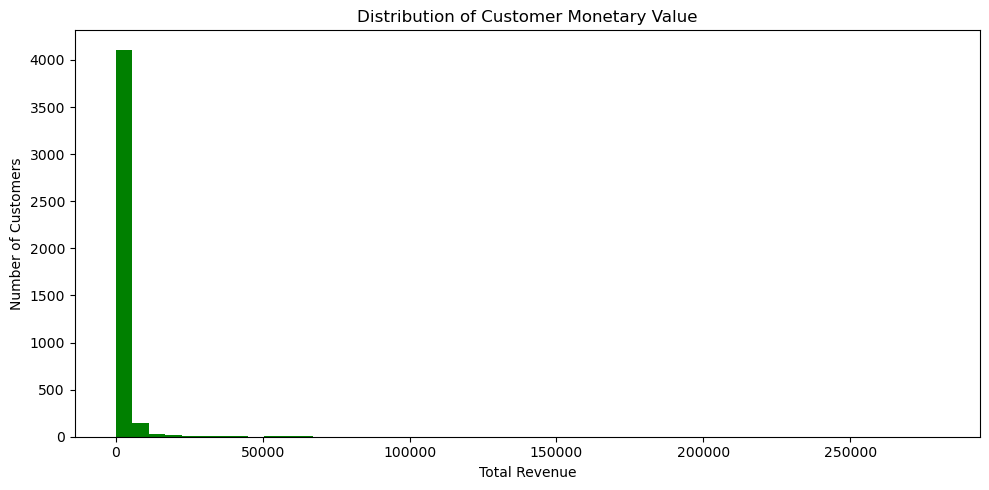

In [46]:
# Monetary

# Because some customers may spend much more than others:

plt.figure(figsize=(10, 5))

plt.hist(rfm["Monetary"],bins=50, color = 'green')

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

6. Create RFM Scores

In [47]:
# Recency

# Lower recency is better.

rfm["R_Score"] = pd.qcut(rfm["Recency"],q=5,labels=[5, 4, 3, 2, 1],duplicates="drop")

In [48]:
# Frequency

# Higher is better.

rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5,labels=[1, 2, 3, 4, 5])

In [49]:
# Monetary

# Higher is better.

rfm["M_Score"] = pd.qcut(rfm["Monetary"],q=5,labels=[1, 2, 3, 4, 5],duplicates="drop")

In [50]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,1,77183.60,1,1,5
1,12347,2,7,4310.00,5,5,5
2,12348,75,4,1797.24,2,4,4
3,12349,19,1,1757.55,4,1,4
4,12350,310,1,334.40,1,1,2


7. Convert Scores to Integers

In [51]:
rfm["R_Score"] = rfm["R_Score"].astype(int)

rfm["F_Score"] = rfm["F_Score"].astype(int)

rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,1,77183.60,1,1,5
1,12347,2,7,4310.00,5,5,5
2,12348,75,4,1797.24,2,4,4
3,12349,19,1,1757.55,4,1,4
4,12350,310,1,334.40,1,1,2


8. Create a Combined RFM Score

In [52]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


9. Create RFM Segments

In [53]:
def customer_segment(row):
    
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]
    
    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    
    # Loyal Customers
    elif r >= 3 and f >= 4:
        return "Loyal Customers"
    
    # Potential Loyalists
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    
    # Recent Customers
    elif r >= 4 and f <= 2:
        return "Recent Customers"
    
    # At Risk
    elif r <= 2 and f >= 3:
        return "At Risk"
    
    # Need Attention
    elif r == 3 and f >= 2:
        return "Need Attention"
    
    # Lost Customers
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    
    else:
        return "Others"

In [54]:
rfm["Customer_Segment"] = (rfm.apply(customer_segment,axis=1))

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,12346,326,1,77183.60,1,1,5,115,Lost Customers
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Recent Customers
4,12350,310,1,334.40,1,1,2,112,Lost Customers


10. Segment Distribution

In [55]:
segment_summary = (
    rfm.groupby("Customer_Segment")
       .agg(Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum"))
        .sort_values(by="Total_Revenue",ascending=False))

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Customer_Segment,,,,,
Champions,957,12.824451,11.123302,6051.871202,5791640.740
Loyal Customers,503,38.023857,5.077535,1780.619406,895651.561
At Risk,643,152.844479,3.404355,1241.139208,798052.511
Lost Customers,1065,217.897653,1.101408,486.687467,518322.152
Potential Loyalists,492,17.123984,2.010163,1030.109004,506813.630
Need Attention,373,53.104558,1.815013,688.568257,256835.960
Others,164,53.914634,1.000000,419.150610,68740.700
Recent Customers,141,18.503546,1.000000,362.777589,51151.640


11. Customer Count by Segment

In [56]:
segment_counts = (rfm["Customer_Segment"].value_counts())

segment_counts

Customer_Segment
Lost Customers         1065
Champions               957
At Risk                 643
Loyal Customers         503
Potential Loyalists     492
Need Attention          373
Others                  164
Recent Customers        141
Name: count, dtype: int64

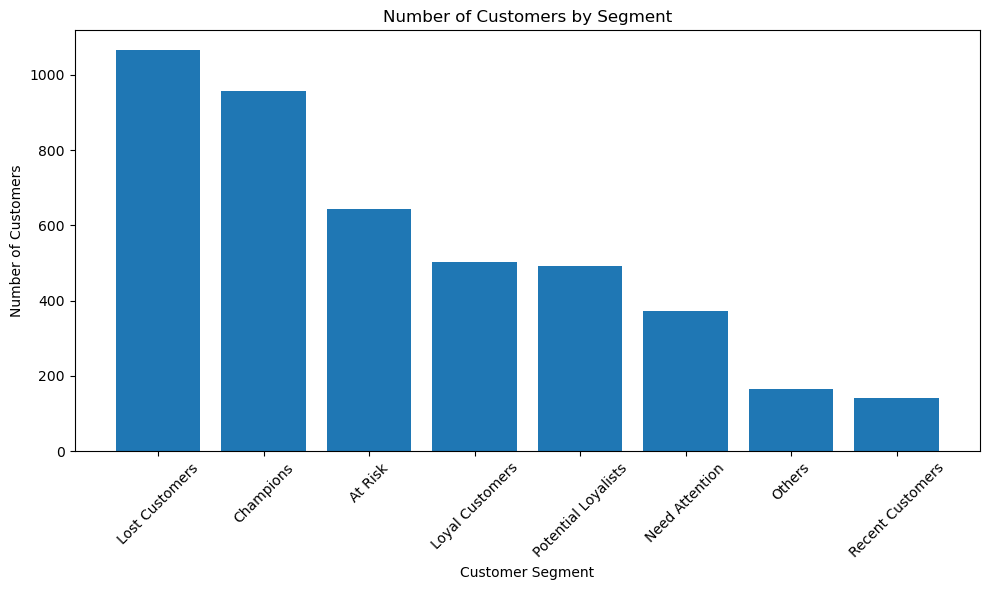

In [57]:
# Visualization

plt.figure(figsize=(10, 6))

plt.bar(segment_counts.index,segment_counts.values)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

12. Revenue by Segment

In [58]:
segment_revenue = (
    rfm.groupby("Customer_Segment")["Monetary"].sum().sort_values(ascending=False))

segment_revenue

Customer_Segment
Champions              5791640.740
Loyal Customers         895651.561
At Risk                 798052.511
Lost Customers          518322.152
Potential Loyalists     506813.630
Need Attention          256835.960
Others                   68740.700
Recent Customers         51151.640
Name: Monetary, dtype: float64

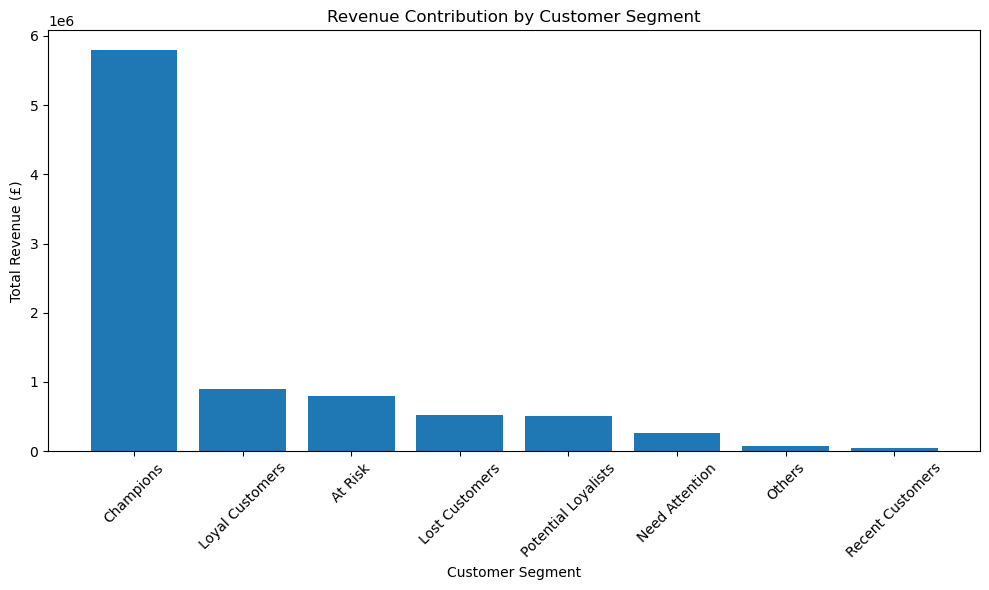

In [59]:
# Visualization

plt.figure(figsize=(10, 6))

plt.bar(segment_revenue.index,segment_revenue.values)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

13. Identify Top Customers

In [60]:
top_rfm_customers = (rfm.sort_values(by="Monetary",ascending=False).head(10))

top_rfm_customers[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "RFM_Score",
        "Customer_Segment"
    ]
]

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Customer_Segment
1689,14646,2,73,280206.02,555,Champions
4201,18102,1,60,259657.30,555,Champions
3728,17450,8,46,194390.79,555,Champions
3008,16446,1,2,168472.50,535,Potential Loyalists
1879,14911,1,201,143711.17,555,Champions
55,12415,24,21,124914.53,455,Champions
1333,14156,10,55,117210.08,555,Champions
3771,17511,3,31,91062.38,555,Champions
2702,16029,39,63,80850.84,355,Loyal Customers
0,12346,326,1,77183.60,115,Lost Customers


14. Create a Customer Segment Profile

In [61]:
segment_profile = (
    rfm.groupby("Customer_Segment")
    .agg( Customer_Count=("CustomerID", "count"),
          Avg_Recency=("Recency", "mean"),
          Avg_Frequency=("Frequency", "mean"),
          Avg_Revenue=("Monetary", "mean"),
          Total_Revenue=("Monetary", "sum") )
         .reset_index().sort_values(by="Total_Revenue",ascending=False))

segment_profile

,Customer_Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Revenue,Total_Revenue
1,Champions,957,12.824451,11.123302,6051.871202,5791640.740
3,Loyal Customers,503,38.023857,5.077535,1780.619406,895651.561
0,At Risk,643,152.844479,3.404355,1241.139208,798052.511
2,Lost Customers,1065,217.897653,1.101408,486.687467,518322.152
6,Potential Loyalists,492,17.123984,2.010163,1030.109004,506813.630
4,Need Attention,373,53.104558,1.815013,688.568257,256835.960
5,Others,164,53.914634,1.000000,419.150610,68740.700
7,Recent Customers,141,18.503546,1.000000,362.777589,51151.640


15. Calculate Revenue Contribution %

In [62]:
segment_profile["Revenue_%"] = (segment_profile["Total_Revenue"] / segment_profile["Total_Revenue"].sum() * 100)

segment_profile.round(2)

,Customer_Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Revenue,Total_Revenue,Revenue_%
1,Champions,957,12.82,11.12,6051.87,5791640.74,65.17
3,Loyal Customers,503,38.02,5.08,1780.62,895651.56,10.08
0,At Risk,643,152.84,3.40,1241.14,798052.51,8.98
2,Lost Customers,1065,217.90,1.10,486.69,518322.15,5.83
6,Potential Loyalists,492,17.12,2.01,1030.11,506813.63,5.70
4,Need Attention,373,53.10,1.82,688.57,256835.96,2.89
5,Others,164,53.91,1.00,419.15,68740.70,0.77
7,Recent Customers,141,18.50,1.00,362.78,51151.64,0.58


16. Business Actions for Each Segment

In [63]:
segment_actions = { "Champions":"Reward loyalty and provide exclusive offers.",
    
                "Loyal Customers":"Encourage referrals and cross-selling.",
    
                "Potential Loyalists":"Use targeted promotions to increase purchase frequency.",
    
                "Recent Customers":"Send welcome offers and encourage a second purchase.",
    
                "Need Attention":"Use personalized campaigns to improve engagement.",
    
                 "At Risk":"Launch win-back campaigns and special offers.",
    
                "Lost Customers":"Consider low-cost reactivation campaigns."}

# action column:

rfm["Recommended_Action"] = ( rfm["Customer_Segment"].map(segment_actions))

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Recommended_Action
0,12346,326,1,77183.60,1,1,5,115,Lost Customers,Consider low-cost reactivation campaigns.
1,12347,2,7,4310.00,5,5,5,555,Champions,Reward loyalty and provide exclusive offers.
2,12348,75,4,1797.24,2,4,4,244,At Risk,Launch win-back campaigns and special offers.
3,12349,19,1,1757.55,4,1,4,414,Recent Customers,Send welcome offers and encourage a second pur...
4,12350,310,1,334.40,1,1,2,112,Lost Customers,Consider low-cost reactivation campaigns.


17. Final RFM Summary

In [64]:
rfm_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "At Risk Customers",
        "Lost Customers",
        "Total Customer Revenue" ],
    
    "Value": [len(rfm),
        
        (rfm["Customer_Segment"] == "Champions").sum(),
        
        (rfm["Customer_Segment"] == "Loyal Customers").sum(),
        
        (rfm["Customer_Segment"] == "Potential Loyalists").sum(),
        
        (rfm["Customer_Segment"] == "At Risk").sum(),
        
        (rfm["Customer_Segment"] == "Lost Customers").sum(),
        
        f"£{rfm['Monetary'].sum():,.2f}"]})

rfm_summary

,Metric,Value
0,Total Customers,4338
1,Champions,957
2,Loyal Customers,503
3,Potential Loyalists,492
4,At Risk Customers,643
5,Lost Customers,1065
6,Total Customer Revenue,"£8,887,208.89"


18. Export the RFM Dataset

In [65]:
rfm.to_csv("customer_rfm_segmentation.csv",index=False)

print("RFM segmentation dataset exported successfully!")

RFM segmentation dataset exported successfully!


Import the csv file to MySQL

In [66]:
from sqlalchemy import create_engine

# MySQL connection details
username = "root"
password = "683456k"
host = "localhost"
port = 3306
database = "online_retail_analysis"

# # CSV file path
# csv_file = "online_retail_cleaned.csv"

# Read CSV
df1 = pd.read_csv(r"D:\ANURAG\Customer Retention + Cohort Analysis project\online_retail_cleaned.csv")

# Create MySQL connection
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Load data into MySQL
df1.to_sql("online_retail",engine,if_exists="replace", index=False)


print("CSV data loaded successfully!")


CSV data loaded successfully!


In [68]:
pd.read_sql("SELECT * FROM online_retail LIMIT 5;", engine)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month,Day_Name,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,2010-12,Wednesday,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
